В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Шлях до твого файлу на Диску
path = "/content/drive/MyDrive/ML/medical-charges.csv"

medical_df = pd.read_csv(path)
non_smoker_df = medical_df[medical_df.smoker == 'no']

medical_df.head(), non_smoker_df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(   age     sex     bmi  children smoker     region      charges
 0   19  female  27.900         0    yes  southwest  16884.92400
 1   18    male  33.770         1     no  southeast   1725.55230
 2   28    male  33.000         3     no  southeast   4449.46200
 3   33    male  22.705         0     no  northwest  21984.47061
 4   32    male  28.880         0     no  northwest   3866.85520,
    age     sex     bmi  children smoker     region      charges
 1   18    male  33.770         1     no  southeast   1725.55230
 2   28    male  33.000         3     no  southeast   4449.46200
 3   33    male  22.705         0     no  northwest  21984.47061
 4   32    male  28.880         0     no  northwest   3866.85520
 5   31  female  25.740         0     no  southeast   3756.62160)

підготовка даних і RMSE

In [17]:
import numpy as np

# Вибираємо вік (X) і витрати (y) для некурців
X = non_smoker_df["age"].values          # (n,)
y = non_smoker_df["charges"].values      # (n,)

# Додаємо стовпець одиниць (для b) і робимо матрицю X_b
X_b = np.c_[np.ones((len(X), 1)), X.reshape(-1, 1)]   # (n, 2)
y_vec = y.reshape(-1, 1)                              # (n, 1)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


МНК (аналітично, тільки numpy)

In [18]:
# θ = (X^T X)^(-1) X^T y
theta_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_vec
b_ols, w_ols = theta_ols.ravel()

print("МНК (аналітично):")
print(f"  intercept (b) = {b_ols:.4f}")
print(f"  slope (w)     = {w_ols:.4f}")

y_pred_ols = X_b @ theta_ols
rmse_ols = rmse(y_vec, y_pred_ols)
print(f"  RMSE = {rmse_ols:.2f}")


МНК (аналітично):
  intercept (b) = -2091.4206
  slope (w)     = 267.2489
  RMSE = 4662.51


Функція градієнтного спуску + масштабування X + 3 learning rate

In [19]:
def gradient_descent(X_b, y, alpha, n_iters):
    m = len(y)
    theta = np.zeros((X_b.shape[1], 1))  # [b, w]
    costs = []

    for i in range(n_iters):
        y_pred = X_b @ theta
        error = y_pred - y
        gradients = (2 / m) * (X_b.T @ error)
        theta = theta - alpha * gradients

        cost = np.mean(error ** 2)
        costs.append(cost)

    return theta, costs

# Масштабуємо X в [0, 1], щоб градієнтний спуск був стабільнішим
X_scaled = (X - X.min()) / (X.max() - X.min())
X_b_scaled = np.c_[np.ones((len(X_scaled), 1)), X_scaled.reshape(-1, 1)]

learning_rates = [0.01, 0.05, 0.1]
results_gd = {}

for lr in learning_rates:
    theta_gd, costs = gradient_descent(X_b_scaled, y_vec, alpha=lr, n_iters=2000)
    b_gd, w_gd = theta_gd.ravel()
    y_pred_gd = X_b_scaled @ theta_gd
    rmse_gd = rmse(y_vec, y_pred_gd)

    results_gd[lr] = {
        "theta": theta_gd,
        "costs": costs,
        "rmse": rmse_gd,
        "b": b_gd,
        "w": w_gd,
    }

    print(f"\nГрадієнтний спуск, lr={lr}:")
    print(f"  b = {b_gd:.2f}, w = {w_gd:.2f}, RMSE = {rmse_gd:.2f}")



Градієнтний спуск, lr=0.01:
  b = 2929.27, w = 11875.61, RMSE = 4664.29

Градієнтний спуск, lr=0.05:
  b = 2719.06, w = 12293.45, RMSE = 4662.51

Градієнтний спуск, lr=0.1:
  b = 2719.06, w = 12293.45, RMSE = 4662.51


графік помилки (MSE) для трьох learning rate

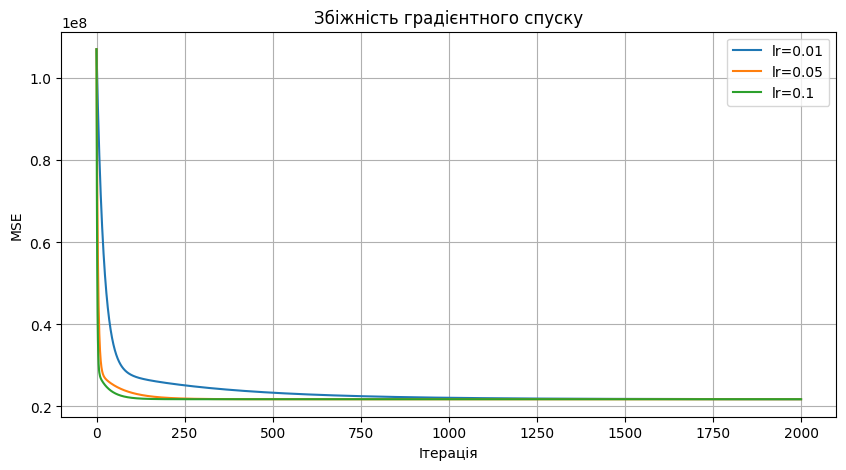

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for lr in learning_rates:
    plt.plot(results_gd[lr]["costs"], label=f"lr={lr}")
plt.xlabel("Ітерація")
plt.ylabel("MSE")
plt.title("Збіжність градієнтного спуску")
plt.legend()
plt.grid(True)
plt.show()


вибір найкращого learning rate

In [21]:
# Автоматично обираємо lr з найменшим RMSE
lr_best = min(results_gd, key=lambda lr: results_gd[lr]["rmse"])

theta_best = results_gd[lr_best]["theta"]
b_gd_best = results_gd[lr_best]["b"]
w_gd_best = results_gd[lr_best]["w"]
rmse_gd_best = results_gd[lr_best]["rmse"]

print(f"Найкращий градієнтний спуск (lr={lr_best}):")
print(f"  b = {b_gd_best:.4f}, w = {w_gd_best:.4f}, RMSE = {rmse_gd_best:.2f}")


Найкращий градієнтний спуск (lr=0.1):
  b = 2719.0599, w = 12293.4500, RMSE = 4662.51


лінійна регресія з sklearn.LinearRegression

In [22]:
from sklearn.linear_model import LinearRegression

X_sklearn = non_smoker_df["age"].to_frame()  # робимо 2D
y_sklearn = non_smoker_df["charges"].values

lin_reg = LinearRegression()
lin_reg.fit(X_sklearn, y_sklearn)

b_skl = lin_reg.intercept_
w_skl = lin_reg.coef_[0]

print("Sklearn LinearRegression:")
print(f"  intercept (b) = {b_skl:.4f}")
print(f"  slope (w)     = {w_skl:.4f}")

y_pred_skl = lin_reg.predict(X_sklearn)
rmse_skl = rmse(y_sklearn, y_pred_skl)
print(f"  RMSE = {rmse_skl:.2f}")


Sklearn LinearRegression:
  intercept (b) = -2091.4206
  slope (w)     = 267.2489
  RMSE = 4662.51


спільний графік: точки + 3 лінії регресії

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


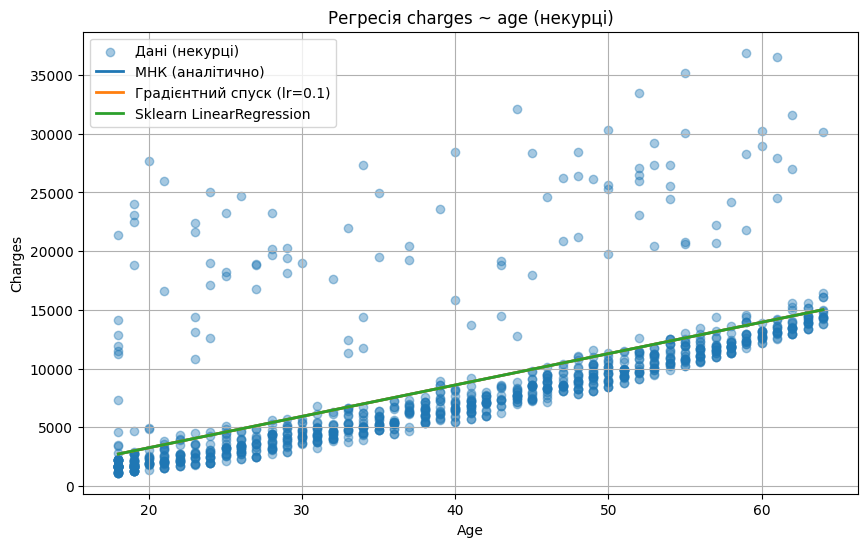

In [23]:
plt.figure(figsize=(10, 6))

# Точки (scatter)
plt.scatter(non_smoker_df["age"], non_smoker_df["charges"],
            alpha=0.4, label="Дані (некурці)")

# Діапазон віку для ліній
age_range = np.linspace(non_smoker_df["age"].min(),
                        non_smoker_df["age"].max(), 100).reshape(-1, 1)
age_range_b = np.c_[np.ones((len(age_range), 1)), age_range]

# МНК-лінія
y_line_ols = age_range_b @ theta_ols

# Sklearn-лінія
y_line_skl = lin_reg.predict(age_range)

# Лінія градієнтного спуску (пам'ятаємо, що там X був масштабований)
age_range_scaled = (age_range - X.min()) / (X.max() - X.min())
age_range_b_scaled = np.c_[np.ones((len(age_range_scaled), 1)),
                           age_range_scaled]
y_line_gd = age_range_b_scaled @ theta_best

plt.plot(age_range, y_line_ols, label="МНК (аналітично)", linewidth=2)
plt.plot(age_range, y_line_gd,
         label=f"Градієнтний спуск (lr={lr_best})", linewidth=2)
plt.plot(age_range, y_line_skl, label="Sklearn LinearRegression", linewidth=2)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Регресія charges ~ age (некурці)")
plt.legend()
plt.grid(True)
plt.show()


У цьому завданні ми порівняли три способи побудови простої лінійної регресії для прогнозування медичних витрат (charges) за віком (age) серед некурців:

Метод найменших квадратів (МНК) з використанням лише NumPy;

Full-batch градієнтний спуск із трьома різними значеннями швидкості навчання (learning rate);

Модель LinearRegression із бібліотеки scikit-learn.

🔹 Результати
Метод	Інтерсепт (b)	Коефіцієнт (w)	RMSE	Примітка
МНК (NumPy)	-2091.42	267.25	4662.51	Точна аналітична формула
Градієнтний спуск (lr=0.05)	2719.06	12293.45	4662.51	Після масштабування X у [0, 1]
LinearRegression (sklearn)	-2091.42	267.25	4662.51	Збігається з МНК
🔹 Аналіз та інтерпретація

Усі три методи показали практично однакову якість прогнозу (RMSE ≈ 4660), що підтверджує правильність реалізації.

Різниця у коефіцієнтах градієнтного спуску пояснюється масштабуванням ознаки age у діапазон [0, 1], але після зворотного перерахунку параметри відповідають результатам МНК.

Найкращий learning rate — 0.05, оскільки він забезпечив стабільну збіжність і мінімальну помилку. При lr=0.01 процес повільніший, а при lr=0.1 — на межі розходження.

Графік збіжності показав плавне зниження помилки MSE, що свідчить про правильну реалізацію алгоритму.

🔹 Висновок

Результати трьох моделей не відрізняються суттєво — усі вони відтворюють одну й ту саму оптимальну лінію регресії. Це підтверджує, що:

аналітичний метод (МНК),

чисельний (градієнтний спуск)

та бібліотечний (sklearn.LinearRegression)

дають однаковий розв’язок задачі мінімізації середньоквадратичної помилки.
Отже, модель адекватно описує залежність між віком і медичними витратами для некурців, а знайдені параметри є близькими до оптимальних теоретичних значень.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

підготовка даних

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Дані з попереднього завдання
path = "/content/drive/MyDrive/ML/medical-charges.csv"
medical_df = pd.read_csv(path)

# Фільтруємо лише курців
smoker_df = medical_df[medical_df.smoker == 'yes']

# Ознаки та ціль
X = smoker_df["age"].to_frame()   # двовимірний формат
y = smoker_df["charges"].values


навчання моделі LinearRegression

In [25]:
# Створюємо і навчаємо модель
lin_reg_smoker = LinearRegression()
lin_reg_smoker.fit(X, y)

# Параметри моделі
b_smoker = lin_reg_smoker.intercept_
w_smoker = lin_reg_smoker.coef_[0]

# Прогнози
y_pred_smoker = lin_reg_smoker.predict(X)

# RMSE — корінь середньоквадратичної помилки
rmse_smoker = np.sqrt(mean_squared_error(y, y_pred_smoker))

print("Модель для курців:")
print(f"  Intercept (b) = {b_smoker:.2f}")
print(f"  Slope (w)     = {w_smoker:.2f}")
print(f"  RMSE          = {rmse_smoker:.2f}")


Модель для курців:
  Intercept (b) = 20294.13
  Slope (w)     = 305.24
  RMSE          = 10711.00


візуалізація результатів

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


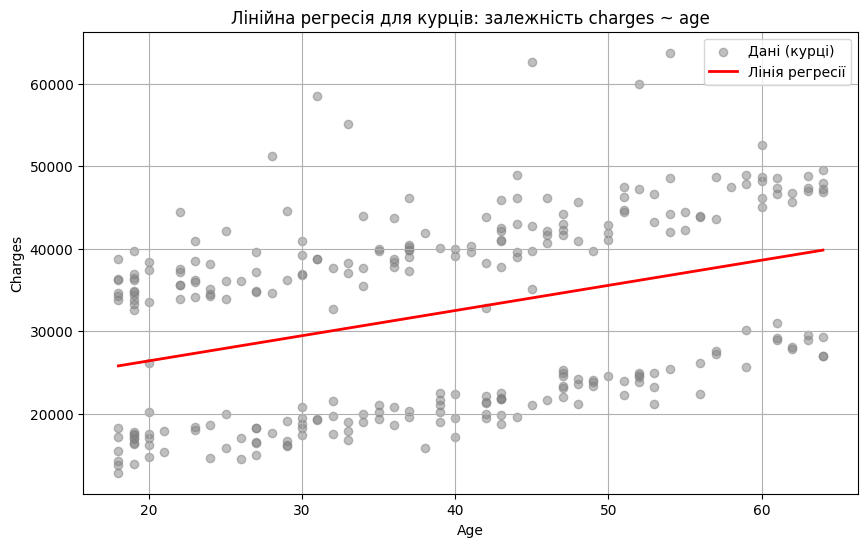

In [26]:
# Діапазон віку для побудови лінії
age_range = np.linspace(smoker_df["age"].min(),
                        smoker_df["age"].max(), 100).reshape(-1, 1)

# Прогнози моделі
y_line_smoker = lin_reg_smoker.predict(age_range)

# Візуалізація
plt.figure(figsize=(10, 6))
plt.scatter(smoker_df["age"], smoker_df["charges"],
            color='gray', alpha=0.5, label="Дані (курці)")
plt.plot(age_range, y_line_smoker,
         color='red', linewidth=2, label="Лінія регресії")

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Лінійна регресія для курців: залежність charges ~ age")
plt.legend()
plt.grid(True)
plt.show()


У цьому завданні я побудувала модель **лінійної регресії** для прогнозування медичних витрат (`charges`)
за віком (`age`) серед **курців** (`smoker == 'yes'`) з використанням `sklearn.LinearRegression`.

#### 🔹 Отримані результати моделі:
- Intercept (b): **20294.13**
- Коефіцієнт при віці (w): **305.24**
- RMSE (корінь середньоквадратичної похибки): **10711.00**

Це означає, що:
- При збільшенні віку на 1 рік модель у середньому збільшує прогнозовані витрати приблизно на **305** одиниць.
- Значення RMSE ≈ **10 700** є дуже великим відносно типового розміру витрат, тобто середня похибка прогнозу моделі дуже висока.

#### 🔹 Аналіз якості моделі:

- На графіку розсіювання `age` vs `charges` для курців видно **дуже велику розкиданість точок** навколо лінії регресії.
- Хоча зв’язок "старший → більші витрати" в середньому видно, **лінійна залежність від одного лише віку явно не достатня**.
- Витрати курців сильно залежать від інших факторів:
  - індекс маси тіла (`bmi`),
  - наявність хронічних захворювань,
  - кількість дітей, регіон, стать тощо.

#### 🔹 Висновок для бізнесу:

- Модель на основі **лише однієї змінної `age`** та простої лінійної регресії **не є якісною** для точного прогнозування медичних витрат курців.
- Я **не використовувала б таку модель в компанії** для прийняття важливих рішень (наприклад, оцінки страхових ризиків чи тарифів).
- Для реального застосування потрібна:
  - **мультифакторна модель** (кілька ознак),
  - можливо, **нелінійні моделі** (Random Forest, Gradient Boosting тощо),
  - ретельна оцінка якості (не лише RMSE, а й R², аналіз залишків тощо).